<a href="https://colab.research.google.com/github/rangaraju1/AI-agents/blob/main/multimodal_rag_openai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Learning Objectives

- Parse a multimodal source document using `llamaparse` (from LlamaCloud).
- Index these sources to a vector database (Chroma) using `langchain` abstractions.

# Setup

In [1]:
!pip install -q openai==1.66.3 \
                tiktoken==0.9.0 \
                pypdf==5.4.0 \
                langchain==0.3.20 \
                langchain-community==0.3.19 \
                langchain-chroma==0.2.2 \
                langchain-openai==0.3.9 \
                chromadb==0.6.3 \
                lark==1.2.2 \
                llama-index-core==0.12.29 \
                llama-parse==0.6.4.post1 \
                llama-index-readers-file==0.4.7

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 75.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 567.4/567.4 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 107.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.1/611.

In [2]:
import base64
import chromadb

from openai import OpenAI

from langchain.text_splitter import RecursiveCharacterTextSplitter

from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma

from llama_parse import LlamaParse

from google.colab import userdata

/usr/local/lib/python3.13/dist-packages/pydantic/_internal/_generate_schema.py:2274: UnsupportedFieldAttributeWarning: The 'validate_default' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'validate_default' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(


In [3]:
import nest_asyncio; nest_asyncio.apply()

To facilitate parsing of multimodal pdf files, we use `llamaparse` hosted on LlamaCloud. Before parsing, ensure that you create a LlamaCloud API key.   

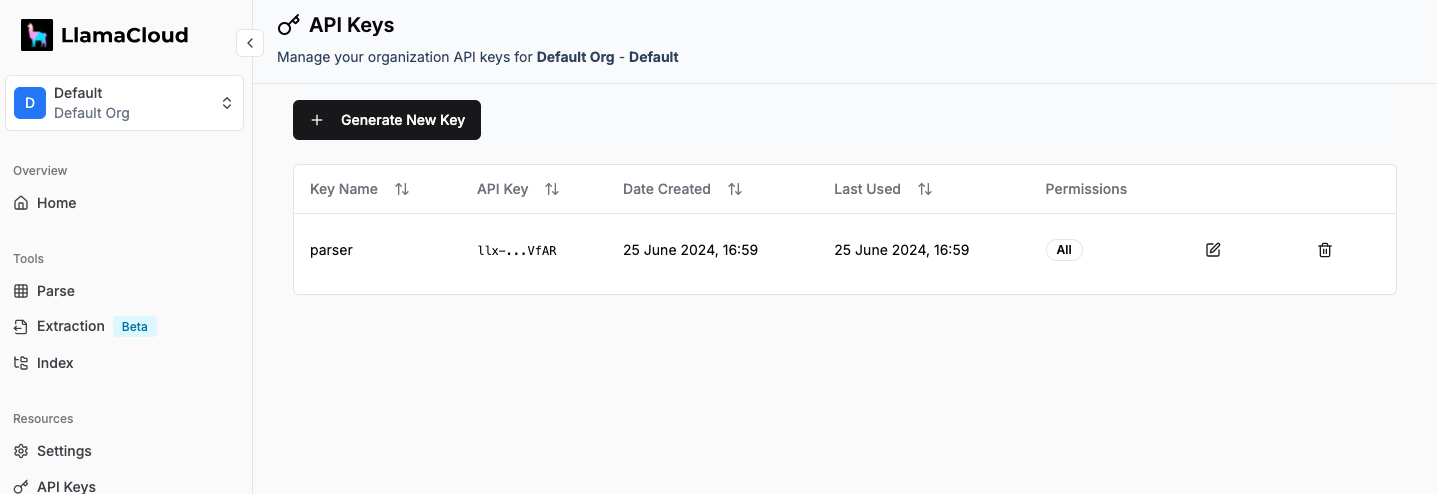

This API key can then be pasted into the userdata of Colab and used just like we have used Open AI API keys.

In [4]:
openai_api_key = userdata.get('openai_api_key')
llamaparse_api_key = userdata.get('llamaparse_api_key')

In [5]:
client = OpenAI(
    api_key=openai_api_key,
    base_url="https://aibe.mygreatlearning.com/openai/v1"
)

In [6]:
embedding_model = OpenAIEmbeddings(
    api_key=openai_api_key,
    base_url="https://aibe.mygreatlearning.com/openai/v1",
    model='text-embedding-3-small'
)

In [7]:
model_name = 'gpt-4o-mini'

# Parse

To illustrate parsing, let us extract the text, images and tables of an Dell XPS13 owners manual. Note that the parser uploads this pdf file onto LlamaCloud where we can track progress of the parsing job.

In [8]:
pdf_file_path = 'xps-13-9340-owners-manual-en-us.pdf'

In [9]:
parser = LlamaParse(
    result_type="markdown",
    skip_diagonal_text=True,
    fast_mode=False,
    num_workers=9,
    check_interval=10,
    api_key=llamaparse_api_key
)

In [10]:
json_objs = parser.get_json_result(pdf_file_path)

Started parsing the file under job_id 3d72d359-9983-4d5a-a3e4-70345de44f4c
...

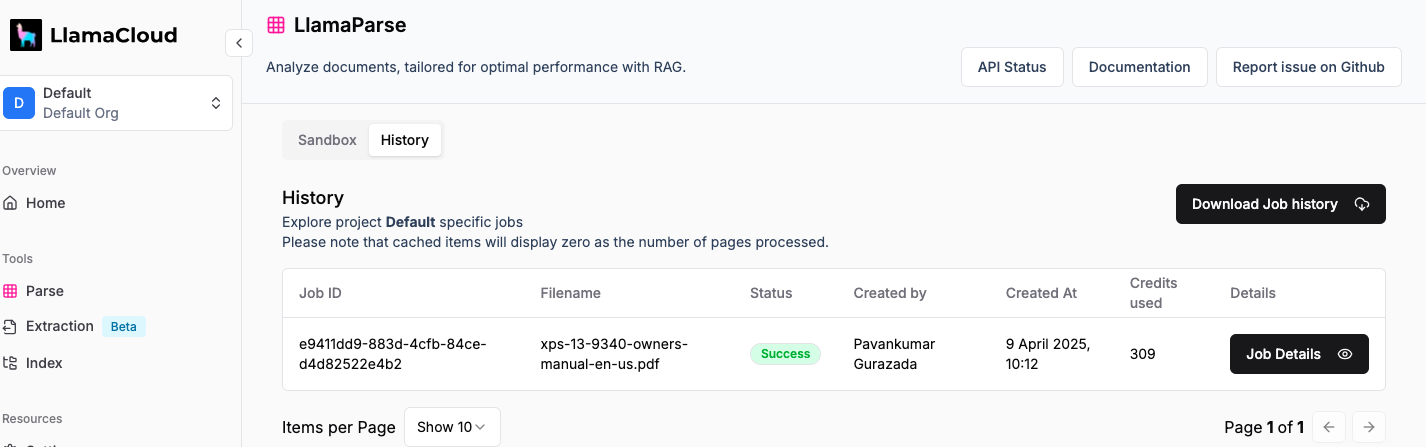

Clicking on Job Details, we can view the different elements of the pdf file that was parsed.

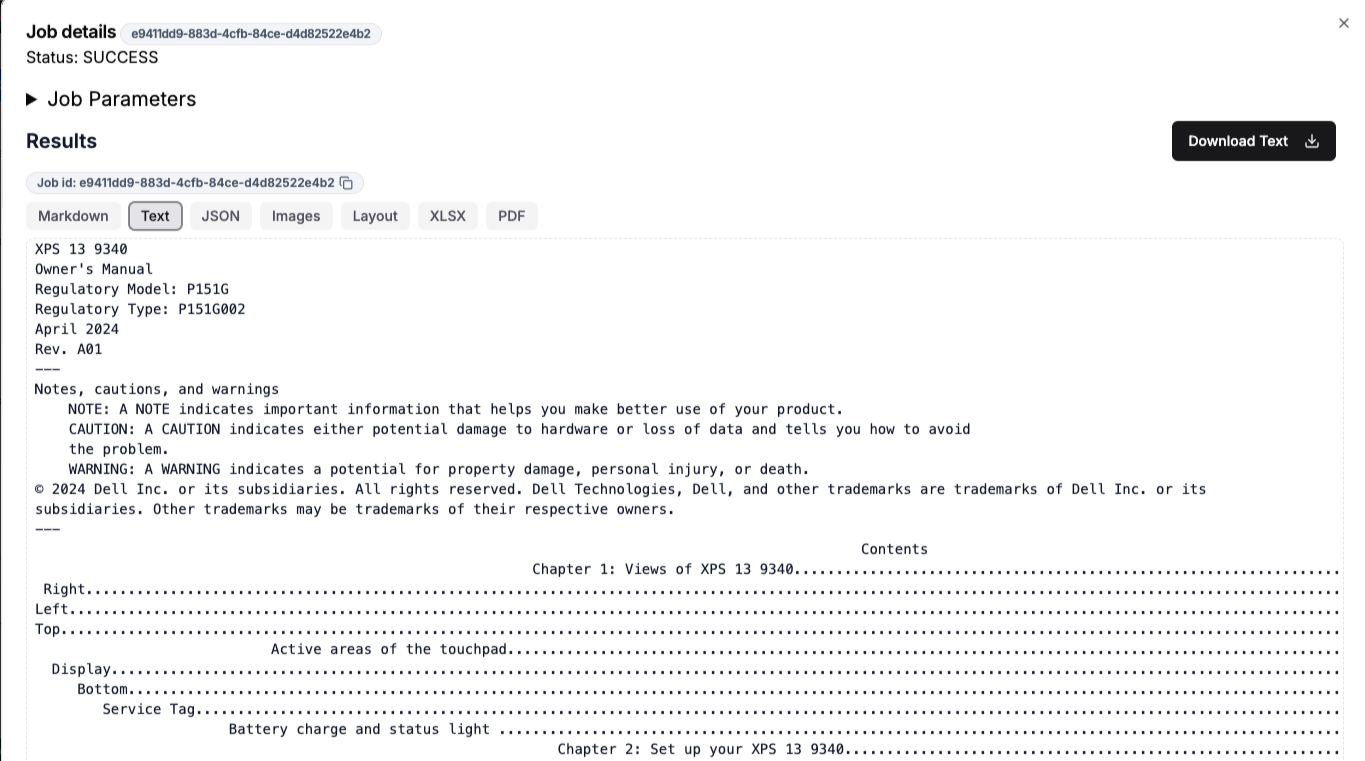

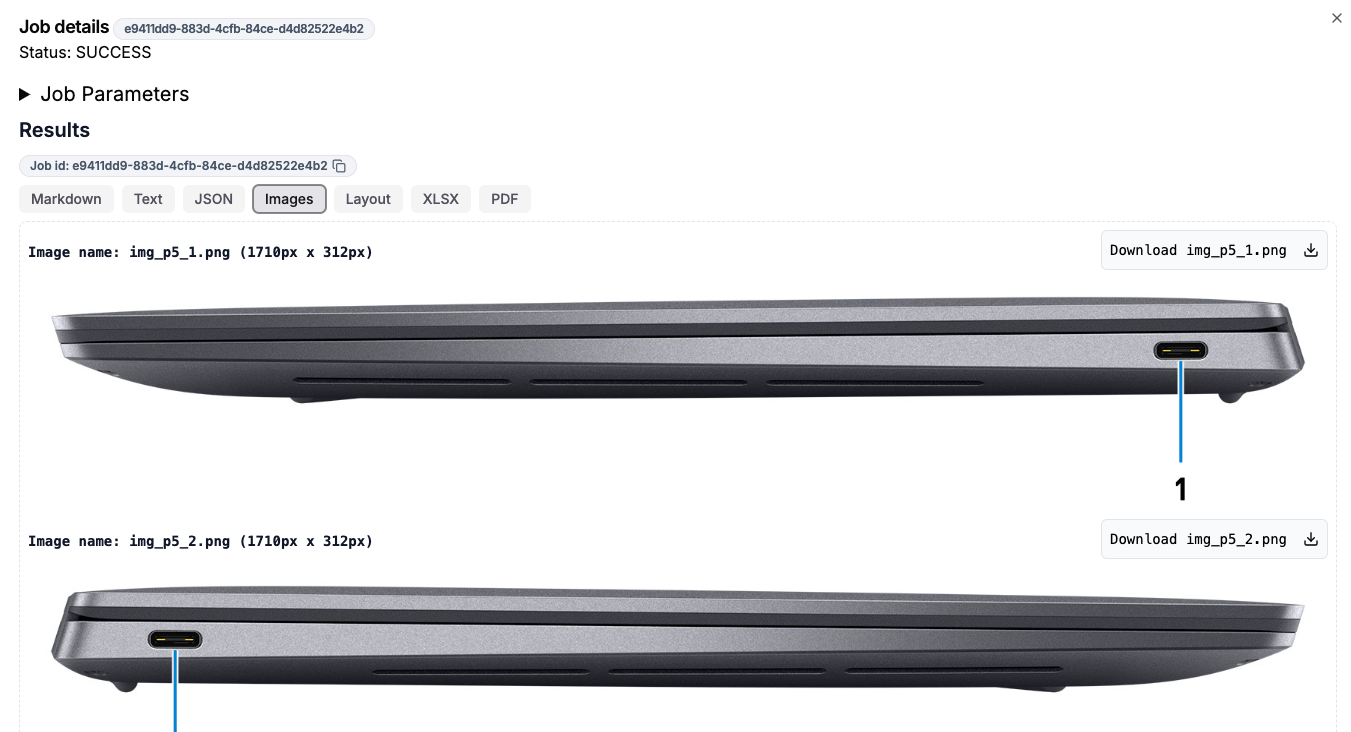

The output from the parser is a list of JSON objects containing the pages in the document. Let us inspect a sample object to understand its structure.

In [11]:
type(json_objs)

list

In [12]:
json_objs[0]['pages'][5]

{'page': 6,
 'text': '    1\n\n    Views of XPS 13 9340\n\n   Right\n\n\n\n\n\n\n\n                                                                                                       1\n    Figure 1. Right view\n\n    1.      Thunderbolt 4 port with Power Delivery (Type-C)\n            Supports USB4, DisplayPort 1.4, Thunderbolt 4 and also enables you to connect to an external display using a display adapter.\n            Provides data transfer rates of up to 40 Gbps for USB4 and Thunderbolt 4.\n                      NOTE: A USB Type-C to DisplayPort adapter (sold separately) is required to connect a DisplayPort device.\n\n                      NOTE: USB4 is backward compatible with USB 3.2, USB 2.0, and Thunderbolt 3.\n\n                      NOTE: Thunderbolt 4 supports four 4K displays, one 5K display, or one 8K display.\n  rangaraju1@gmail.com\n  JAPTBL0C6I\n    Left\n\n\n\n\n\n\n\n\n\n    Figure 2. Left view\n\n    1.     Thunderbolt 4 port with Power Delivery (Type-C)\n       

As the above output indicates, `llamaparse` extracts the different elements of the document pagewise. Of particular interest to us is the text of the pages, stored under the key `md` and `text`. Images get their own key: `images`, while tables are stored as `items` of type `table`.

Let us now extract all the text and tables in the document by looping over the extracted pages.

In [13]:
pages_list = json_objs[0]["pages"]

## Extract Text

We begin by collecting all the text in the pages into a list by page.

In [14]:
page_texts = []

for json_item in pages_list:
    current_page_text = f"Page {json_item['page']}: \n" + json_item['md'] + '\n'
    page_texts.append(current_page_text)

In [15]:
len(page_texts)

103

Let us now inspect a page.

In [16]:
page_texts[14]

'Page 15: \n\n\n# Chipset\n\nThe following table lists the details of the chipset that is supported for your XPS 13 9340.\n\n## Table 5. Chipset\n\n| Description    | Values                      |\n| -------------- | --------------------------- |\n| Chipset        | Integrated in the processor |\n| Processor      | Intel Core Ultra 5/7        |\n| DRAM bus width | 128-bit                     |\n| Flash EPROM    | 64 MB                       |\n| PCIe bus       | Up to Gen4                  |\n\n\n# Operating system\n\nYour XPS 13 9340 supports the following operating systems:\n\n- Windows 11 Pro\n- Windows 11 Pro National Education\n- Windows 11 Home\n- Ubuntu Linux 22.04 LTS\n\n# Memory\n\nThe following table lists the memory specifications of your XPS 13 9340.\n\n## Table 6. Memory specifications\n\n| Description                     | Values                                                                                                                                                 

## Generate Table Descriptions

In [17]:
tables = {}

In [18]:
for json_item in pages_list: # iterates through each page in the pages_list
    current_title = None # initializes current_title to None for each page
    for component in json_item['items']: # iterates through each component (e.g., heading, table) within a page
        if component['type'] == 'heading' and 'Table' in component['value']: # checks if the component is a heading and contains the word "Table"
            current_title = component['value'] # if true, assigns the heading value to current_title
        elif component['type'] == 'table' and current_title: # checks if the component is a table and current_title is not None (meaning a valid heading was found)
            tables[current_title] = component['rows'] # if true, adds the table data to the tables dictionary using current_title as the key
            current_title = None # resets current_title to None to avoid adding subsequent tables with the same title

Let us begin by inspecting specific tables that we extracted (corresponding to Table 16, 17 and 19 in the document).

In [19]:
len(tables.keys())

55

In [20]:
print(tables['Table 16. Power adapter specifications'])

[['Description', 'Values', ''], ['Type', '60 W AC adapter, USB Type-C', ''], ['Power-adapter dimensions:', '', ''], ['', 'Height', '22 mm (0.87 in.)'], ['', 'Width', '55 mm (2.17 in.)'], ['', 'Depth', '66 mm (2.60 in.)'], ['Input voltage', '', '100 VAC–240 VAC'], ['Input frequency', '', '50 Hz–60 Hz'], ['Input current (maximum)', '', '1.70 A'], ['Output current (continuous)', '', '3 A'], ['Rated output voltage', '', '• 20 VDC • 15 VDC']]


In [21]:
print(tables['Table 17. Battery specifications'])

[['Description', 'Values', ''], ['Battery type', '3-cell, 55 Wh "smart" lithium-ion', ''], ['Battery voltage', '11.55 VDC', ''], ['Battery weight (maximum)', '0.219 kg (0.483 lb)', ''], ['Battery dimensions:', '', ''], ['', 'Height', '238.40 mm (9.39 in.)'], ['', 'Width', '4.86 mm (0.19 in.)'], ['', 'Depth', '97.41 mm (3.84 in.)'], ['Temperature range:', '', ''], ['', 'Operating', '0°C to 65°C (32°F to 149°F)'], ['', 'Storage', '-20°C to 65°C (-4°F to 149°F)'], ['Battery operating time', 'Varies depending on operating conditions and can significantly reduce under certain power-intensive conditions.', ''], ['Battery charging time (approximate)<br/>ⓘ NOTE: Control the charging time, duration, start and end time, and so on using the Power feature of MyDell application. For more information about the Power feature see, *Me and My Dell* on Dell Support Site.', '3 hours (when the computer is off)', ''], ['Coin-cell battery', 'Not applicable', ''], ['⚠️ CAUTION: Operating and storage temperat

In [22]:
try:
    print(tables['<font color="blue">Table 19. Fingerprint reader specifications</font>'])
except KeyError as e:
    print(f"Error: {e}. The specified table key was not found in the `tables` dictionary.")
    print("Here are the available keys in the `tables` dictionary:")
    for key in tables.keys():
        print(f"- {key}")


Error: '<font color="blue">Table 19. Fingerprint reader specifications</font>'. The specified table key was not found in the `tables` dictionary.
Here are the available keys in the `tables` dictionary:
- <font color="blue">Table 1. Battery charge and status light behavior</font>
- Table 2. Locate Dell apps in Windows
- **Table 3. Dimensions and weight**
- **Table 4. Processor**
- Table 5. Chipset
- Table 6. Memory specifications
- Table 7. External ports
- Table 8. Internal slots
- Table 9. Wireless module specifications
- Table 9. Wireless module specifications (continued)
- Table 10. Audio specifications
- Table 11. Storage specifications
- Table 12. Keyboard specifications
- Table 13. List of keyboard shortcuts
- Table 14. Camera specifications
- Table 14. Camera specifications (continued)
- Table 15. Touchpad specifications
- Table 16. Power adapter specifications
- Table 16. Power adapter specifications (continued)
- Table 17. Battery specifications
- Table 18. Display specificati

We now need to describe the rows of this table as text to capture the contents of the table. Let us execute this logic on one table before rolling out to all the tables in the document.

In [23]:
table_describer_system_message = """
You are tasked to explain operating manual documents for Dell laptops.
You are required to generate a detailed description of rows of tables presented to you as the input.
Be detailed in your description and describe ALL the rows of the table presented to you.
The input will contain the title of the table followed by a list of rows in the table.
Remember to include the title of the table in your output.
Do not add any text other than the title and the description of the table in your output.
"""

In [24]:
# Generating the description of a sample table

table_key = 'Table 16. Power adapter specifications'

table_description_prompt = [
    {'role': 'developer', 'content': table_describer_system_message},
    {'role': 'user', 'content': table_key + str(tables[table_key])}
]


In [25]:
try:
    response = client.chat.completions.create(
        model=model_name,
        messages=table_description_prompt,
        temperature=0
    )
    description = response.choices[0].message.content
except Exception as e:
    description = ''

In [26]:
print(description)

Table 16. Power adapter specifications

This table provides detailed specifications for the power adapter used with Dell laptops. It is organized into several rows, each detailing a specific aspect of the power adapter.

- The first row is a header row that includes the columns 'Description', 'Values', and an empty column for additional notes.
  
- The second row describes the type of power adapter, which is a "60 W AC adapter, USB Type-C". This indicates the wattage and the connection type of the adapter.

- The third row introduces the dimensions of the power adapter, labeled as "Power-adapter dimensions:". This row does not contain specific values but serves as a category for the following dimension details.

- The next three rows provide the physical dimensions of the power adapter:
  - The first of these rows specifies the height as "22 mm (0.87 in.)".
  - The second row lists the width as "55 mm (2.17 in.)".
  - The third row indicates the depth as "66 mm (2.60 in.)".

- The foll

Let us now roll out this description generator to all the tables in the document.

In [27]:
def generate_table_description(tables, table_key):
    """Generates a description of a table using an OpenAI model.

    This function takes a dictionary of tables and a table key as input. It then
    constructs a prompt containing a system message and the table data.
    This prompt is sent to an OpenAI model, and the model's response is returned as
    the table description.

    Args:
        tables: A dictionary of tables.
        table_key: The key of the table to describe.

    Returns:
        A string containing the description of the table. If an error occurs
        during the OpenAI API call, an empty string is returned.
    """

    table_description_prompt = [
        {'role': 'developer', 'content': table_describer_system_message},
        {'role': 'user', 'content': table_key + str(tables[table_key])}
    ]

    try:
        response = client.chat.completions.create(
            model=model_name,
            messages=table_description_prompt,
            temperature=0
        )
        description = response.choices[0].message.content
        return description
    except Exception as e:
        description = ''
        return description

In [28]:
table_descriptions = [generate_table_description(tables, table_key) for table_key in tables.keys()]

In [29]:
assert len(table_descriptions) == len(tables.keys())

In [30]:
table_descriptions[3]

'**Table 4. Processor**\n\nThis table provides detailed specifications for the processors available in Dell laptops, presenting three different options for users to choose from. Each row outlines a specific characteristic of the processors, allowing for a clear comparison between the options.\n\n- **Description**: This column lists the various attributes of the processors.\n- **Option one**: This column details the specifications for the first processor option, the Intel Core Ultra 5 125H.\n- **Option two**: This column provides the specifications for the second processor option, the Intel Core Ultra 7 155H.\n- **Option three**: This column describes the specifications for the third processor option, the Intel Core Ultra 7 165H.\n\nThe rows of the table are as follows:\n\n1. **Processor type**: This row identifies the specific models of the processors. The first option is the Intel Core Ultra 5 125H, the second is the Intel Core Ultra 7 155H, and the third is the Intel Core Ultra 7 165

## Generate Image Descriptions

Let us begin by downloading all the images.

In [31]:
image_dicts = parser.get_images(
    json_objs,
    download_path="dellxps_images"
)

> Images for page 1: [{'name': 'page_1.jpg', 'height': 841.89, 'width': 595.276, 'x': 0, 'y': 0, 'original_width': 2033, 'original_height': 2112, 'rotation': 0, 'type': 'full_page_screenshot', 'ocr': [{'x': 1275, 'y': 1984, 'w': 747, 'h': 106, 'confidence': 0.954, 'text': 'DeLLTechnologies'}]}, {'name': 'page_1_image_1_v2.jpg', 'height': 27.638, 'width': 192.567, 'x': 367.911, 'y': 781.47, 'original_width': 733, 'original_height': 106, 'rotation': 0, 'type': 'layout_v3_image'}]
> Images for page 2: [{'name': 'page_2.jpg', 'height': 841.89, 'width': 595.276, 'x': 0, 'y': 0, 'original_width': 1988, 'original_height': 2966, 'rotation': 0, 'type': 'full_page_screenshot'}, {'name': 'page_2_image_1_v2.jpg', 'height': 16.942, 'width': 16.774, 'x': 35.906, 'y': 151.928, 'original_width': 64, 'original_height': 65, 'rotation': 0, 'type': 'layout_v3_image'}, {'name': 'page_2_image_3_v2.jpg', 'height': 16.048, 'width': 15.196, 'x': 36.644, 'y': 95.495, 'original_width': 58, 'original_height': 62,

Let us now look at the information available about a specific image.

In [32]:
image_dicts[0]

{'name': 'page_1.jpg',
 'height': 841.89,
 'width': 595.276,
 'x': 0,
 'y': 0,
 'original_width': 2033,
 'original_height': 2112,
 'rotation': 0,
 'type': 'full_page_screenshot',
 'ocr': [{'x': 1275,
   'y': 1984,
   'w': 747,
   'h': 106,
   'confidence': 0.954,
   'text': 'DeLLTechnologies'}],
 'path': 'dellxps_images/3d72d359-9983-4d5a-a3e4-70345de44f4c-page_1.jpg',
 'job_id': '3d72d359-9983-4d5a-a3e4-70345de44f4c',
 'original_file_path': 'xps-13-9340-owners-manual-en-us.pdf',
 'page_number': 1}

Let us now generate a detailed description of this sample image. We will use GPT 4o mini for this task.

In [33]:
sample_image_path = image_dicts[0]['path']

In [34]:
def image_describer(image_file_path):
    """Generates a detailed description of an image using GPT-4o-mini.

    This function takes the file path of an image as input, reads the image data,
    encodes it to base64, and constructs a data URI. It then sends a prompt
    containing the image data URI to GPT-4o-mini. The model's
    response, which contains a detailed description of the image, is returned.

    Args:
        image_file_path: The file path of the image to describe.

    Returns:
        A string containing the description of the image generated by OpenAI
        GPT-4o-mini.
    """

    with open(image_file_path, 'rb') as image_file:
        image_data = image_file.read()

    # Encode the binary image data to base64
    base64_encoded_data = base64.b64encode(image_data).decode('utf-8')

    # Construct the data URI
    data_uri = f"data:image/png;base64,{base64_encoded_data}"

    image_description_system_message = """
    You are tasked to explain images present in the operating manual for Dell laptops.
    You are required to generate a detailed description of the image presented to you as the input.
    Be detailed in your description and describe the image presented to you.
    Do not add any text other than the description of the image in your output.
    """

    image_description_prompt = [
        {
            'role': 'system',
            'content': image_description_system_message
        },
        {
            'role': 'user',
            'content': [
                {'type': "image_url", "image_url": {'url': data_uri}}
            ]
        }
    ]

    response = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=image_description_prompt,
        temperature=0
    )

    return response.choices[0].message.content

In [35]:
image_describer(sample_image_path)

'The image displays the cover page of the owner\'s manual for the Dell XPS 13 9340 laptop. The top section features the model name "XPS 13 9340" prominently in a bold blue font. Below it, the text "Owner\'s Manual" is presented in a smaller, black font. The background is predominantly white, providing a clean and simple layout. \n\nAt the bottom of the page, there are regulatory details including "Regulatory Model: P151G," "Regulatory Type: P151G002," and the date "April 2024," followed by "Rev. A01." This information is in a smaller font and is aligned to the left. The bottom right corner contains the Dell Technologies logo in blue against a white background, with a note indicating that the document is intended for internal use only.'

We can now loop over all the paths of the downloaded images and create descriptions of these images.

In [36]:
image_descriptions = [image_describer(image_info['path']) for image_info in image_dicts]

In [37]:
len(image_descriptions)

535

# Chunk and Index

Before chunking and indexing, let us collect all the text, table and image descriptions as single block of texts.

In [38]:
page_texts[0]

'Page 1: \n\n\n# <font color="blue">XPS 13 9340</font>\n## Owner\'s Manual\n\nRegulatory Model: P151G\nRegulatory Type: P151G002\nApril 2024\nRev. A01\n\nDELL Technologies\n\nThis file is meant for personal use by rangaraju1@gmail.com only.\nSharing or publishing the contents in part or full is liable for legal action.\n\n'

In [39]:
full_text = ''

for text in page_texts:
    full_text += ('\n---\n' + text)

In [40]:
all_table_descriptions = ''

for description in table_descriptions:
    all_table_descriptions += ('\n---\n' + description)

In [41]:
all_image_descriptions = ''

for description in image_descriptions:
    all_image_descriptions += ('\n---\n' + description)

In [42]:
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',
    chunk_size=512,
    chunk_overlap=16
)

In [43]:
all_chunks = text_splitter.create_documents(
    [full_text, all_table_descriptions, all_image_descriptions],
    metadatas=[{'source': 'text'}, {'source': 'table_descriptions'}, {'source': 'image_descriptions'}]
)

In the code above, note that we are adding the source of the text (i.e., document text, table or image) as metadata.

In [44]:
dell_collection = 'xps13-owners-manual'

In [45]:
chromadb_client = chromadb.PersistentClient(
    path="./dell_db"
)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


In [46]:
vectorstore = Chroma(
    collection_name=dell_collection,
    collection_metadata={"hnsw:space": "cosine"},
    embedding_function=embedding_model,
    client=chromadb_client,
    persist_directory="./dell_db"
)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


In [47]:
chromadb_client.count_collections()

1

In [48]:
chromadb_client.list_collections()

['xps13-owners-manual']

In [49]:
len(all_chunks)

362

In [50]:
vectorstore.add_documents(
    documents=all_chunks,
    ids=['text_' + str(i) for i in range(len(all_chunks))]
)

['text_0',
 'text_1',
 'text_2',
 'text_3',
 'text_4',
 'text_5',
 'text_6',
 'text_7',
 'text_8',
 'text_9',
 'text_10',
 'text_11',
 'text_12',
 'text_13',
 'text_14',
 'text_15',
 'text_16',
 'text_17',
 'text_18',
 'text_19',
 'text_20',
 'text_21',
 'text_22',
 'text_23',
 'text_24',
 'text_25',
 'text_26',
 'text_27',
 'text_28',
 'text_29',
 'text_30',
 'text_31',
 'text_32',
 'text_33',
 'text_34',
 'text_35',
 'text_36',
 'text_37',
 'text_38',
 'text_39',
 'text_40',
 'text_41',
 'text_42',
 'text_43',
 'text_44',
 'text_45',
 'text_46',
 'text_47',
 'text_48',
 'text_49',
 'text_50',
 'text_51',
 'text_52',
 'text_53',
 'text_54',
 'text_55',
 'text_56',
 'text_57',
 'text_58',
 'text_59',
 'text_60',
 'text_61',
 'text_62',
 'text_63',
 'text_64',
 'text_65',
 'text_66',
 'text_67',
 'text_68',
 'text_69',
 'text_70',
 'text_71',
 'text_72',
 'text_73',
 'text_74',
 'text_75',
 'text_76',
 'text_77',
 'text_78',
 'text_79',
 'text_80',
 'text_81',
 'text_82',
 'text_83',
 '

In [51]:
collection = chromadb_client.get_collection(dell_collection)

In [52]:
collection.peek(limit=3)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given


{'ids': ['text_0', 'text_1', 'text_2'],
 'embeddings': array([[ 0.05169677,  0.01516724,  0.01989746, ...,  0.00713348,
         -0.01835632, -0.00981903],
        [ 0.03393555,  0.00437164,  0.01218414, ...,  0.0136261 ,
         -0.01780701,  0.01196289],
        [ 0.0249939 ,  0.01165771,  0.02563477, ...,  0.01612854,
          0.00037909, -0.00907135]]),
 'documents': ['---\nPage 1: \n\n\n# <font color="blue">XPS 13 9340</font>\n## Owner\'s Manual\n\nRegulatory Model: P151G\nRegulatory Type: P151G002\nApril 2024\nRev. A01\n\nDELL Technologies\n\nThis file is meant for personal use by rangaraju1@gmail.com only.\nSharing or publishing the contents in part or full is liable for legal action.\n\n\n---\nPage 2: \n\n\n# Notes, cautions, and warnings\n\n**NOTE:** A NOTE indicates important information that helps you make better use of your product.\n\n**CAUTION:** A **CAUTION** indicates **either potential damage to hardware** or **loss of data** and tells you **how to avoid the problem*

# Query

In [53]:
vectorstore_persisted = Chroma(
    collection_name=dell_collection,
    collection_metadata={"hnsw:space": "cosine"},
    embedding_function=embedding_model,
    client=chromadb_client,
    persist_directory="./dell_db"
)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


In [54]:
retriever = vectorstore_persisted.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 5}
)

In [55]:
user_query = "The LED on my adapter is white. What does this mean?"

In [56]:
retriever.invoke(user_query)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


[Document(id='text_170', metadata={'source': 'image_descriptions'}, page_content='4. **Battery Charge Level**: \n   - The first row indicates "Fully Charged" for the AC Adapter.\n   - The second row indicates "< Fully Charged" for the AC Adapter.\n   - The third row indicates "11-100%" for the Battery.\n   - The fourth row indicates "< 10%" for the Battery.\n\nThe table is organized in a clear and structured manner, providing information about the power sources, their corresponding LED behaviors, system power states, and battery charge levels.\n---\nThe image shows a top-down view of a Dell laptop keyboard. The keyboard features a sleek, modern design with a dark gray color scheme. The keys are flat and have a minimalistic appearance, with white lettering for visibility. \n\nTo the left of the keyboard, there is a power adapter with a rectangular shape, featuring the Dell logo on its front. A cable extends from the adapter, connecting to the laptop. The cable is black and has a USB-C c